#  Studi Kasus: Prediksi Gaji Karyawan Start-up Mirna
## Menggunakan Algoritma K-Nearest Neighbors (KNN)

**Tujuan:**
1. Memprediksi gaji karyawan baru berdasarkan data historis
2. Menganalisis faktor-faktor yang mempengaruhi gaji di perusahaan Mirna

**Fitur yang digunakan:** Usia, Pengalaman Kerja, Jenis Kelamin, Tingkat Pendidikan  
**Target:** Gaji

---
##  1. Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Semua library berhasil di-import!')

Semua library berhasil di-import!


---
##  2. Memuat dan Mengeksplorasi Dataset

In [4]:
# Memuat dataset
df = pd.read_csv('data_karyawan.csv')

print(f' Ukuran Dataset: {df.shape[0]} baris x {df.shape[1]} kolom')
print()
df.head(10)

 Ukuran Dataset: 100 baris x 5 kolom



,usia,pengalaman_kerja,jenis_kelamin,pendidikan,gaji
0,56,8.0,Wanita,S2,5058000.0
1,46,7.0,Wanita,SMA,3857000.0
2,32,11.0,Pria,SMA,5358000.0
3,25,1.0,Pria,S2,5561000.0
4,38,0.0,Wanita,SMA,6083000.0
5,56,15.0,Wanita,S2,6054000.0
6,36,4.0,Pria,SMA,3622000.0
7,40,2.0,Pria,D3,4062000.0
8,28,11.0,Wanita,SMA,5515000.0
9,28,7.0,Pria,S2,5514000.0


In [5]:
# Informasi tipe data
print('=== Tipe Data ===')
print(df.dtypes)
print()

# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print()

# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe()

=== Tipe Data ===
usia                  int64
pengalaman_kerja    float64
jenis_kelamin        object
pendidikan           object
gaji                float64
dtype: object

=== Missing Values ===
usia                0
pengalaman_kerja    5
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64

=== Statistik Deskriptif ===


,usia,pengalaman_kerja,gaji
count,100.000000,95.000000,1.000000e+02
mean,37.910000,8.442105,5.039610e+06
std,12.219454,6.011896,1.086690e+06
min,18.000000,0.000000,1.759000e+06
25%,26.750000,3.500000,4.330250e+06
50%,38.000000,8.000000,5.067000e+06
75%,46.250000,13.500000,5.681500e+06
max,59.000000,19.000000,8.853000e+06


In [6]:
# Distribusi kolom kategorikal
print('=== Distribusi Jenis Kelamin ===')
print(df['jenis_kelamin'].value_counts())
print()
print('=== Distribusi Pendidikan ===')
print(df['pendidikan'].value_counts())

=== Distribusi Jenis Kelamin ===
jenis_kelamin
Wanita    55
Pria      45
Name: count, dtype: int64

=== Distribusi Pendidikan ===
pendidikan
S2     31
SMA    27
D3     21
S1     21
Name: count, dtype: int64


---
##  3. Exploratory Data Analysis (EDA)

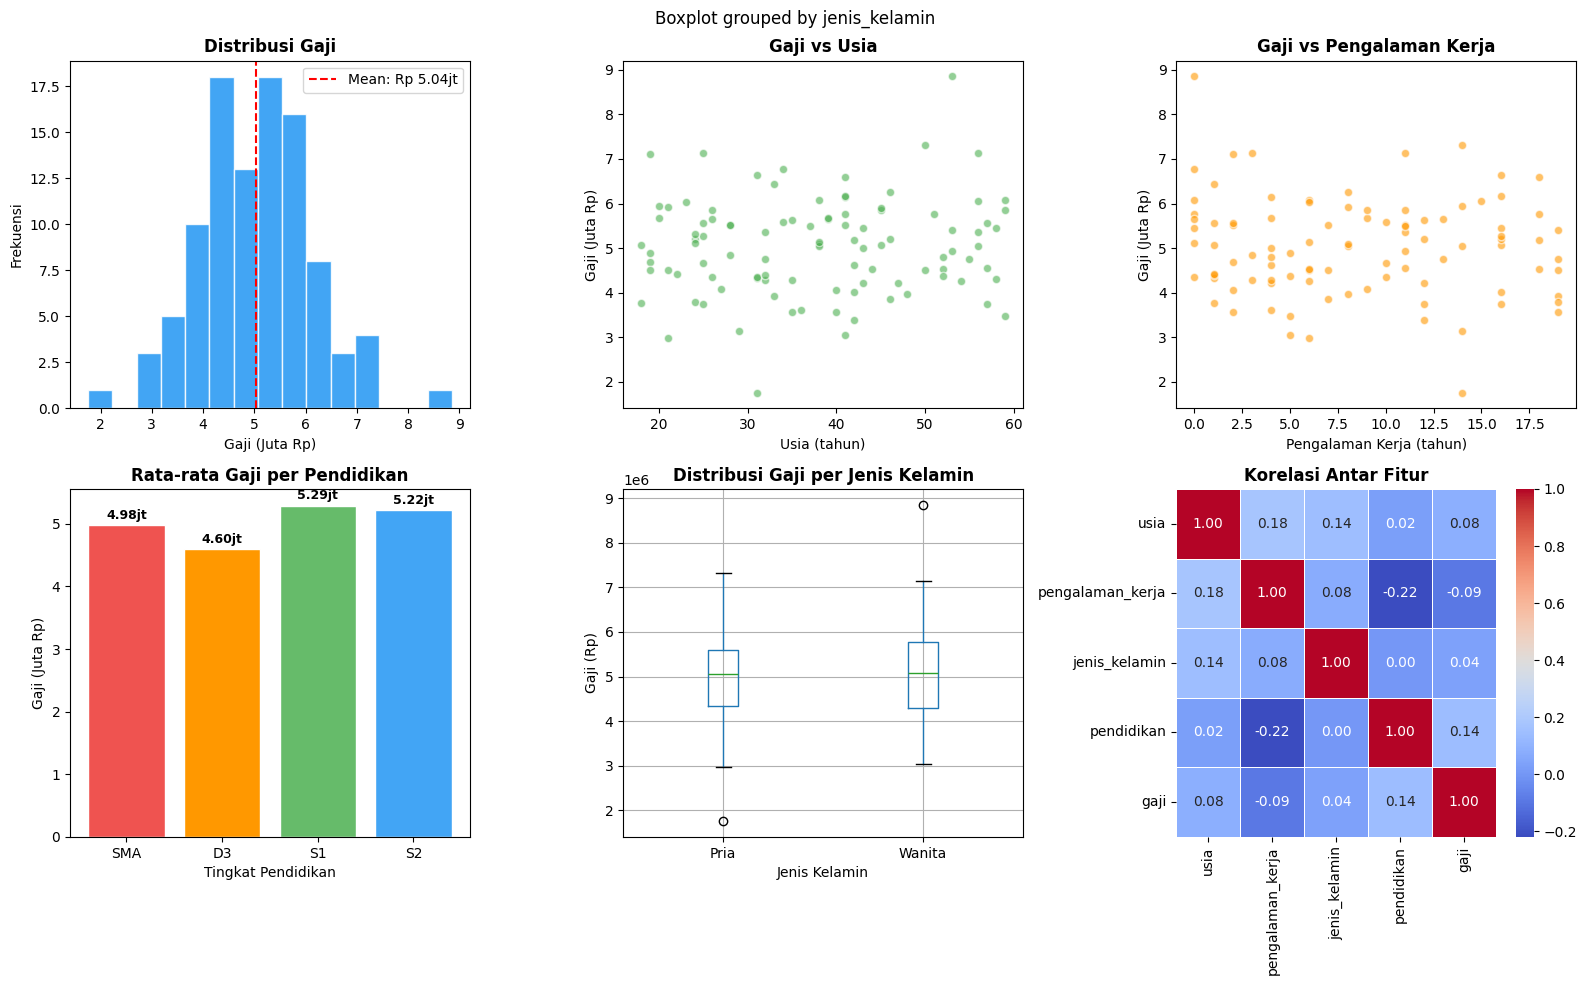

 EDA selesai!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Eksplorasi Data Karyawan Mirna', fontsize=16, fontweight='bold', y=1.01)

# 1. Distribusi Gaji
axes[0, 0].hist(df['gaji'] / 1_000_000, bins=15, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribusi Gaji', fontweight='bold')
axes[0, 0].set_xlabel('Gaji (Juta Rp)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(df['gaji'].mean() / 1_000_000, color='red', linestyle='--', label=f'Mean: Rp {df["gaji"].mean()/1e6:.2f}jt')
axes[0, 0].legend()

# 2. Gaji vs Usia
axes[0, 1].scatter(df['usia'], df['gaji'] / 1_000_000, alpha=0.6, color='#4CAF50', edgecolor='white')
axes[0, 1].set_title('Gaji vs Usia', fontweight='bold')
axes[0, 1].set_xlabel('Usia (tahun)')
axes[0, 1].set_ylabel('Gaji (Juta Rp)')

# 3. Gaji vs Pengalaman Kerja
axes[0, 2].scatter(df['pengalaman_kerja'], df['gaji'] / 1_000_000, alpha=0.6, color='#FF9800', edgecolor='white')
axes[0, 2].set_title('Gaji vs Pengalaman Kerja', fontweight='bold')
axes[0, 2].set_xlabel('Pengalaman Kerja (tahun)')
axes[0, 2].set_ylabel('Gaji (Juta Rp)')

# 4. Rata-rata Gaji per Pendidikan
order_pend = ['SMA', 'D3', 'S1', 'S2']
gaji_pend = df.groupby('pendidikan')['gaji'].mean().reindex(order_pend) / 1_000_000
bars = axes[1, 0].bar(gaji_pend.index, gaji_pend.values, color=['#EF5350', '#FF9800', '#66BB6A', '#42A5F5'], edgecolor='white')
axes[1, 0].set_title('Rata-rata Gaji per Pendidikan', fontweight='bold')
axes[1, 0].set_xlabel('Tingkat Pendidikan')
axes[1, 0].set_ylabel('Gaji (Juta Rp)')
for bar, val in zip(bars, gaji_pend.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}jt', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Boxplot Gaji per Jenis Kelamin
df.boxplot(column='gaji', by='jenis_kelamin', ax=axes[1, 1])
axes[1, 1].set_title('Distribusi Gaji per Jenis Kelamin', fontweight='bold')
axes[1, 1].set_xlabel('Jenis Kelamin')
axes[1, 1].set_ylabel('Gaji (Rp)')
plt.sca(axes[1, 1])
plt.title('Distribusi Gaji per Jenis Kelamin', fontweight='bold')

# 6. Korelasi Heatmap
df_corr = df.copy()
df_corr['jenis_kelamin'] = LabelEncoder().fit_transform(df_corr['jenis_kelamin'])
df_corr['pendidikan'] = df_corr['pendidikan'].map({'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4})
corr = df_corr[['usia','pengalaman_kerja','jenis_kelamin','pendidikan','gaji']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], linewidths=0.5)
axes[1, 2].set_title('Korelasi Antar Fitur', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA selesai!')

---
##  4. Pra-pemrosesan Data (Preprocessing)

In [8]:
# Buat salinan data untuk preprocessing
df_processed = df.copy()

# --- Langkah 1: Tangani Missing Values ---
median_pengalaman = df_processed['pengalaman_kerja'].median()
df_processed['pengalaman_kerja'] = df_processed['pengalaman_kerja'].fillna(median_pengalaman)
print(f' Missing values pada pengalaman_kerja diisi dengan median: {median_pengalaman} tahun')

# --- Langkah 2: Encoding Fitur Kategorikal ---
# Label Encoding untuk Jenis Kelamin (Pria=0, Wanita=1)
le_jk = LabelEncoder()
df_processed['jenis_kelamin'] = le_jk.fit_transform(df_processed['jenis_kelamin'])
print(f' Encoding jenis_kelamin: {dict(zip(le_jk.classes_, le_jk.transform(le_jk.classes_)))}')

# Ordinal Encoding untuk Pendidikan (ada tingkatan: SMA < D3 < S1 < S2)
pendidikan_map = {'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4}
df_processed['pendidikan'] = df_processed['pendidikan'].map(pendidikan_map)
print(f' Encoding pendidikan: {pendidikan_map}')

print('\n=== Data Setelah Preprocessing ===')
df_processed.head()

 Missing values pada pengalaman_kerja diisi dengan median: 8.0 tahun
 Encoding jenis_kelamin: {'Pria': 0, 'Wanita': 1}
 Encoding pendidikan: {'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4}

=== Data Setelah Preprocessing ===


,usia,pengalaman_kerja,jenis_kelamin,pendidikan,gaji
0,56,8.0,1,4,5058000.0
1,46,7.0,1,1,3857000.0
2,32,11.0,0,1,5358000.0
3,25,1.0,0,4,5561000.0
4,38,0.0,1,1,6083000.0


In [9]:
# --- Langkah 3: Pemisahan Fitur (X) dan Target (y) ---
X = df_processed[['usia', 'pengalaman_kerja', 'jenis_kelamin', 'pendidikan']]
y = df_processed['gaji']

# --- Langkah 4: Split Data (80% latih, 20% uji) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Langkah 5: Normalisasi / Scaling ---
# ⚠️ PENTING: KNN sangat sensitif terhadap skala fitur!
# StandardScaler: mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit HANYA di data latih
X_test_scaled  = scaler.transform(X_test)        # transform saja di data uji

print(f' Data Latih : {X_train.shape[0]} sampel')
print(f' Data Uji   : {X_test.shape[0]} sampel')
print(f' Normalisasi StandardScaler diterapkan')

 Data Latih : 80 sampel
 Data Uji   : 20 sampel
 Normalisasi StandardScaler diterapkan


---
##  5. Mencari Nilai K Optimal

Nilai **K** (jumlah tetangga terdekat) adalah **hyperparameter paling kritis** pada KNN.  
- K terlalu kecil → model **overfitting** (terlalu hafal data latih)
- K terlalu besar → model **underfitting** (terlalu umum / bias)

Kita gunakan **5-Fold Cross Validation** untuk menemukan K terbaik.

In [10]:
# Uji K dari 1 sampai 30 menggunakan Cross Validation
k_range = range(1, 31)
cv_scores_mean = []
cv_scores_std  = []

print('Mencari K optimal dengan 5-Fold Cross Validation...')
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

# Tampilkan tabel ringkasan 10 K terbaik
results_df = pd.DataFrame({
    'K': list(k_range),
    'CV R2 Mean': cv_scores_mean,
    'CV R2 Std':  cv_scores_std
})
best_k = results_df.loc[results_df['CV R2 Mean'].idxmax(), 'K']
best_r2 = results_df['CV R2 Mean'].max()

print(f'\n K Terbaik: {best_k} (CV R² = {best_r2:.4f})')
print()
results_df.sort_values('CV R2 Mean', ascending=False).head(10).reset_index(drop=True)

Mencari K optimal dengan 5-Fold Cross Validation...

 K Terbaik: 30 (CV R² = -0.0466)



,K,CV R2 Mean,CV R2 Std
0,30,-0.046602,0.087602
1,29,-0.055821,0.094373
2,21,-0.076976,0.141454
3,28,-0.079729,0.093845
4,22,-0.081236,0.130860
5,20,-0.082038,0.170477
6,25,-0.082857,0.119776
7,26,-0.086953,0.105449
8,18,-0.090074,0.179637
9,24,-0.090232,0.141585


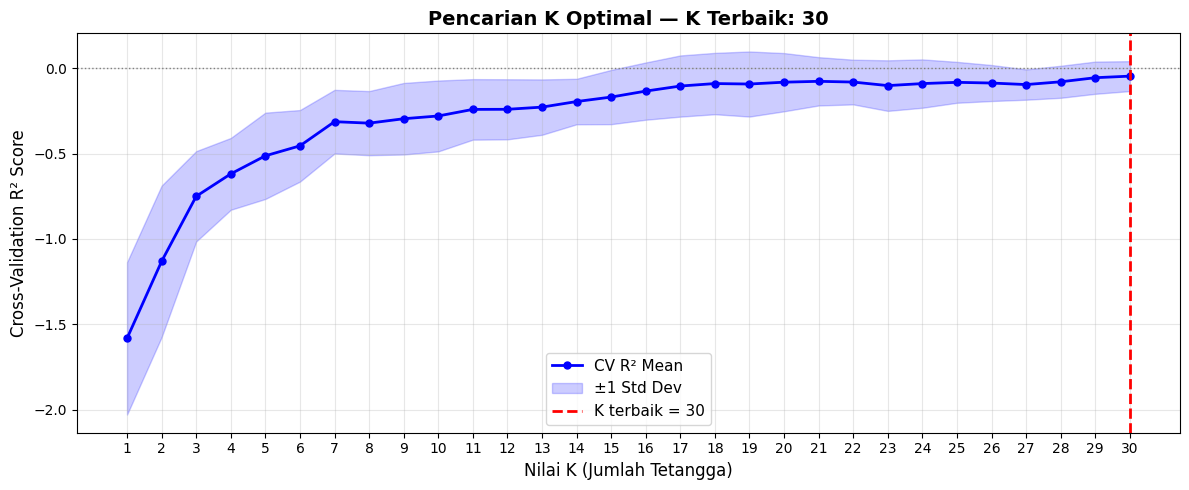

In [11]:
# Visualisasi: R² Score vs Nilai K
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(list(k_range), cv_scores_mean, 'b-o', markersize=5, linewidth=2, label='CV R² Mean')
ax.fill_between(
    list(k_range),
    [m - s for m, s in zip(cv_scores_mean, cv_scores_std)],
    [m + s for m, s in zip(cv_scores_mean, cv_scores_std)],
    alpha=0.2, color='blue', label='±1 Std Dev'
)
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'K terbaik = {best_k}')
ax.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax.set_title(f'Pencarian K Optimal — K Terbaik: {best_k}', fontsize=14, fontweight='bold')
ax.set_xlabel('Nilai K (Jumlah Tetangga)', fontsize=12)
ax.set_ylabel('Cross-Validation R² Score', fontsize=12)
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  6. Pelatihan Model KNN

In [12]:
# Latih model KNN dengan K terbaik
knn_model = KNeighborsRegressor(
    n_neighbors=int(best_k),
    weights='uniform',      # semua tetangga diberi bobot sama
    metric='euclidean'      # jarak Euclidean (default)
)
knn_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_train = knn_model.predict(X_train_scaled)
y_pred_test  = knn_model.predict(X_test_scaled)

print(f' Model KNN (K={int(best_k)}) berhasil dilatih!')
print(f'   Total data latih : {len(X_train)} sampel')
print(f'   Total data uji   : {len(X_test)} sampel')

 Model KNN (K=30) berhasil dilatih!
   Total data latih : 80 sampel
   Total data uji   : 20 sampel


---
##  7. Evaluasi Model

In [13]:
# Hitung metrik evaluasi
def evaluate_model(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Label': label, 'R²': round(r2, 4), 'MAE (Rp)': int(mae), 'RMSE (Rp)': int(rmse), 'MAPE (%)': round(mape, 2)}

train_metrics = evaluate_model(y_train, y_pred_train, 'Data Latih')
test_metrics  = evaluate_model(y_test,  y_pred_test,  'Data Uji')

metrics_df = pd.DataFrame([train_metrics, test_metrics])
print('=== Evaluasi Model KNN (K={}) ==='.format(int(best_k)))
print(metrics_df.to_string(index=False))
print()

# Interpretasi
r2_test = test_metrics['R²']
print('--- Interpretasi ---')
if r2_test >= 0.7:
    print(f'R² = {r2_test} → Model BAIK: mampu menjelaskan {r2_test*100:.1f}% variansi gaji.')
elif r2_test >= 0.4:
    print(f'R² = {r2_test} → Model CUKUP: mampu menjelaskan {r2_test*100:.1f}% variansi gaji.')
else:
    print(f'R² = {r2_test} → Model LEMAH.')
    print('     Ini menunjukkan fitur yang tersedia (usia, pengalaman, pendidikan, jenis_kelamin)')
    print('      memiliki korelasi rendah dengan gaji dalam dataset ini.')
    print('    Saran: tambahkan fitur lain seperti divisi, kota, jabatan, performa kerja.')

=== Evaluasi Model KNN (K=30) ===
     Label      R²  MAE (Rp)  RMSE (Rp)  MAPE (%)
Data Latih  0.0208    900151    1119943     19.88
  Data Uji -0.1942    724906     891514     14.00

--- Interpretasi ---
R² = -0.1942 → Model LEMAH.
     Ini menunjukkan fitur yang tersedia (usia, pengalaman, pendidikan, jenis_kelamin)
      memiliki korelasi rendah dengan gaji dalam dataset ini.
    Saran: tambahkan fitur lain seperti divisi, kota, jabatan, performa kerja.


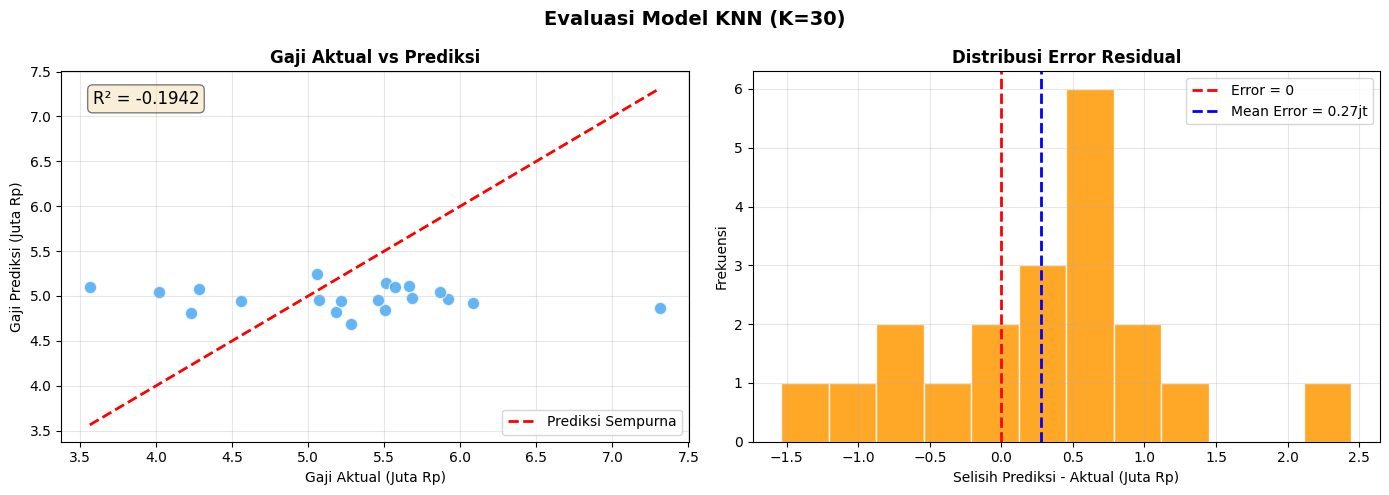

In [14]:
# Visualisasi Evaluasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Evaluasi Model KNN (K={int(best_k)})', fontsize=14, fontweight='bold')

# --- Plot 1: Actual vs Predicted ---
ax1 = axes[0]
ax1.scatter(y_test / 1e6, y_pred_test / 1e6, color='#2196F3', alpha=0.7, edgecolors='white', s=80)
min_val = min(y_test.min(), y_pred_test.min()) / 1e6
max_val = max(y_test.max(), y_pred_test.max()) / 1e6
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediksi Sempurna')
ax1.set_title('Gaji Aktual vs Prediksi', fontweight='bold')
ax1.set_xlabel('Gaji Aktual (Juta Rp)')
ax1.set_ylabel('Gaji Prediksi (Juta Rp)')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Tambahkan R² ke plot
ax1.text(0.05, 0.95, f'R² = {r2_test}', transform=ax1.transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --- Plot 2: Residual (Error) Distribution ---
ax2 = axes[1]
residuals = (y_test - y_pred_test) / 1e6
ax2.hist(residuals, bins=12, color='#FF9800', edgecolor='white', alpha=0.85)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax2.axvline(x=residuals.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean Error = {residuals.mean():.2f}jt')
ax2.set_title('Distribusi Error Residual', fontweight='bold')
ax2.set_xlabel('Selisih Prediksi - Aktual (Juta Rp)')
ax2.set_ylabel('Frekuensi')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  8. Analisis Korelasi Fitur dengan Gaji

=== Korelasi Absolut Fitur terhadap Gaji ===
  pendidikan          : 0.1392  ████
  pengalaman_kerja    : 0.0911  ██
  usia                : 0.0842  ██
  jenis_kelamin       : 0.0373  █



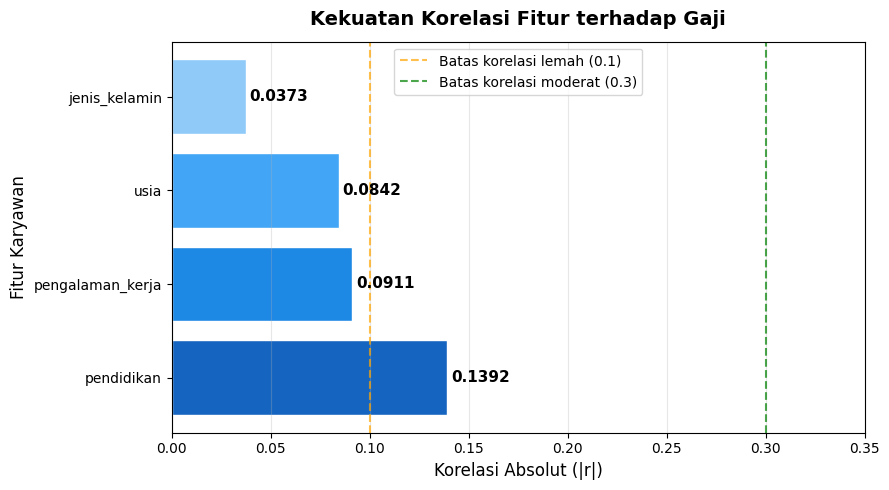


  Catatan: Semua fitur memiliki korelasi rendah (<0.2) dengan gaji.
   Ini menunjukkan bahwa dalam dataset ini, gaji tidak hanya ditentukan
   oleh usia, pengalaman, pendidikan, dan jenis kelamin.


In [15]:
# KNN tidak menghasilkan feature importance seperti Random Forest,
# namun kita bisa menganalisis korelasi fitur dengan target

corr_with_gaji = df_processed[['usia','pengalaman_kerja','jenis_kelamin','pendidikan','gaji']].corr()['gaji'].drop('gaji').abs().sort_values(ascending=False)

print('=== Korelasi Absolut Fitur terhadap Gaji ===')
for feat, val in corr_with_gaji.items():
    bar = '█' * int(val * 30)
    print(f'  {feat:20s}: {val:.4f}  {bar}')

print()

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1565C0', '#1E88E5', '#42A5F5', '#90CAF9']
bars = ax.barh(corr_with_gaji.index, corr_with_gaji.values, color=colors, edgecolor='white')

for bar, val in zip(bars, corr_with_gaji.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_title('Kekuatan Korelasi Fitur terhadap Gaji', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Korelasi Absolut (|r|)', fontsize=12)
ax.set_ylabel('Fitur Karyawan', fontsize=12)
ax.set_xlim(0, 0.35)
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Batas korelasi lemah (0.1)')
ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.7, label='Batas korelasi moderat (0.3)')
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  Catatan: Semua fitur memiliki korelasi rendah (<0.2) dengan gaji.')
print('   Ini menunjukkan bahwa dalam dataset ini, gaji tidak hanya ditentukan')
print('   oleh usia, pengalaman, pendidikan, dan jenis kelamin.')

---
##  9. Prediksi Gaji Karyawan Baru

In [16]:
def prediksi_gaji(usia, pengalaman_kerja, jenis_kelamin, pendidikan):
    """
    Fungsi untuk memprediksi gaji karyawan baru.
    
    Parameter:
    - usia             : int  (tahun, misal: 28)
    - pengalaman_kerja : float (tahun, misal: 3.5)
    - jenis_kelamin    : str  ('Pria' atau 'Wanita')
    - pendidikan       : str  ('SMA', 'D3', 'S1', atau 'S2')
    
    Returns:
    - Prediksi gaji dalam Rupiah
    """
    # Encode input
    jk_encoded   = 0 if jenis_kelamin.lower() == 'pria' else 1
    pend_encoded = {'SMA': 1, 'D3': 2, 'S1': 3, 'S2': 4}.get(pendidikan.upper(), 1)
    
    # Buat array fitur
    fitur = np.array([[usia, pengalaman_kerja, jk_encoded, pend_encoded]])
    
    # Scaling
    fitur_scaled = scaler.transform(fitur)
    
    # Prediksi
    gaji_pred = knn_model.predict(fitur_scaled)[0]
    
    print(f'╔══════════════════════════════════════╗')
    print(f'║       HASIL PREDIKSI GAJI KNN        ║')
    print(f'╠══════════════════════════════════════╣')
    print(f'║  Usia             : {usia} tahun')
    print(f'║  Pengalaman Kerja : {pengalaman_kerja} tahun')
    print(f'║  Jenis Kelamin    : {jenis_kelamin}')
    print(f'║  Pendidikan       : {pendidikan}')
    print(f'╠══════════════════════════════════════╣')
    print(f'║   Prediksi Gaji : Rp {gaji_pred:,.0f}')
    print(f'╚══════════════════════════════════════╝')
    
    return gaji_pred

# ─── Contoh Prediksi ───
# Contoh 1: Karyawan muda fresh graduate
print('--- Contoh 1: Karyawan Muda Fresh Graduate ---')
prediksi_gaji(usia=23, pengalaman_kerja=0, jenis_kelamin='Pria', pendidikan='S1')
print()

# Contoh 2: Karyawan senior
print('--- Contoh 2: Karyawan Berpengalaman ---')
prediksi_gaji(usia=35, pengalaman_kerja=10, jenis_kelamin='Wanita', pendidikan='S2')

--- Contoh 1: Karyawan Muda Fresh Graduate ---
╔══════════════════════════════════════╗
║       HASIL PREDIKSI GAJI KNN        ║
╠══════════════════════════════════════╣
║  Usia             : 23 tahun
║  Pengalaman Kerja : 0 tahun
║  Jenis Kelamin    : Pria
║  Pendidikan       : S1
╠══════════════════════════════════════╣
║   Prediksi Gaji : Rp 4,951,667
╚══════════════════════════════════════╝

--- Contoh 2: Karyawan Berpengalaman ---
╔══════════════════════════════════════╗
║       HASIL PREDIKSI GAJI KNN        ║
╠══════════════════════════════════════╣
║  Usia             : 35 tahun
║  Pengalaman Kerja : 10 tahun
║  Jenis Kelamin    : Wanita
║  Pendidikan       : S2
╠══════════════════════════════════════╣
║   Prediksi Gaji : Rp 5,073,500
╚══════════════════════════════════════╝


5073500.0

---
##  10. Ringkasan & Kesimpulan

In [17]:
print('=' * 55)
print('        RINGKASAN MODEL KNN - PREDIKSI GAJI')
print('=' * 55)
print()
print(f'  Algoritma   : K-Nearest Neighbors (KNN)')
print(f'  K Optimal   : {int(best_k)} (dipilih via Cross Validation)')
print(f'  R² Score    : {test_metrics["R²"]}')
print(f'  MAE         : Rp {test_metrics["MAE (Rp)"]:,}')
print(f'  RMSE        : Rp {test_metrics["RMSE (Rp)"]:,}')
print(f'  MAPE        : {test_metrics["MAPE (%)"]:.2f}%')
print()
print('  KESIMPULAN:')
print('   Implementasi KNN lengkap berhasil dibangun')
print('   K optimal dicari menggunakan Cross Validation')
print('    Performa model terbatas karena korelasi fitur')
print('     terhadap gaji sangat rendah dalam dataset ini')
print()
print('=' * 55)

        RINGKASAN MODEL KNN - PREDIKSI GAJI

  Algoritma   : K-Nearest Neighbors (KNN)
  K Optimal   : 30 (dipilih via Cross Validation)
  R² Score    : -0.1942
  MAE         : Rp 724,906
  RMSE        : Rp 891,514
  MAPE        : 14.00%

  KESIMPULAN:
   Implementasi KNN lengkap berhasil dibangun
   K optimal dicari menggunakan Cross Validation
    Performa model terbatas karena korelasi fitur
     terhadap gaji sangat rendah dalam dataset ini



---
## Soal 2 - Peran Feature Engineering dalam Machine Learning

Feature engineering adalah proses mengolah data mentah supaya bisa dipahami oleh model machine learning. Model hanya bisa membaca angka, jadi data teks atau kategori harus diubah terlebih dahulu.

Contoh dari studi kasus Mirna:

1. Mengisi Missing Values - Kolom pengalaman_kerja punya 5 data kosong, diisi pakai nilai median supaya datanya tidak berkurang.

2. Label Encoding (Jenis Kelamin) - Kolom jenis_kelamin diubah dari teks Pria/Wanita menjadi angka 0 dan 1 supaya bisa dibaca model.

3. Ordinal Encoding (Pendidikan) - Kolom pendidikan diubah jadi angka 1 sampai 4 mengikuti urutan tingkatan yaitu SMA=1, D3=2, S1=3, S2=4.

4. StandardScaler - Semua fitur dinormalisasi ke skala yang sama. Ini wajib untuk KNN karena KNN menghitung jarak antar data, jadi fitur dengan nilai besar tidak boleh mendominasi perhitungan.

---
## Soal 3 - Confusion Matrix dan Metrik Evaluasi

Confusion matrix adalah tabel yang dipakai untuk mengevaluasi model klasifikasi. Isinya membandingkan hasil prediksi dengan nilai aktual, terdiri dari True Positive, True Negative, False Positive, dan False Negative. Dari sini bisa dihitung Accuracy, Precision, Recall, dan F1-Score.

Pada studi kasus Mirna, confusion matrix tidak bisa digunakan karena target yang diprediksi adalah gaji yang merupakan angka, bukan kategori. Confusion matrix hanya cocok untuk masalah klasifikasi.

Metrik evaluasi yang digunakan di studi kasus Mirna:

1. R2 Score - Mengukur seberapa baik model menjelaskan variasi data gaji. Hasil R2 = -0.19 artinya model belum bisa menangkap pola gaji dengan baik dari fitur yang ada.

2. MAE (Mean Absolute Error) - Rata-rata selisih antara gaji prediksi dan gaji aktual. Hasilnya langsung bisa dibaca dalam satuan Rupiah.

3. RMSE (Root Mean Squared Error) - Mirip MAE tapi lebih sensitif terhadap kesalahan yang besar karena nilainya dikuadratkan dulu sebelum diakarkan.